### Import required libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

### Read the processed India crop yield data

In [2]:
data = pd.read_csv('../data/processed/Processed_India_Crop_Yield_Data.csv')

# Display data info and sample
data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,kg_per_ha_yield
0,10502,India,Cassava,1990,205381,1083.0,75000.0,25.58,20538.1
1,10503,India,Cassava,1990,205381,1083.0,75000.0,26.88,20538.1
2,10504,India,Cassava,1990,205381,1083.0,75000.0,25.79,20538.1
3,10505,India,Cassava,1990,205381,1083.0,75000.0,24.10,20538.1
4,10506,India,Cassava,1990,205381,1083.0,75000.0,25.25,20538.1


### Define input features (X) and target variable (y)

In [4]:
# Example features: rainfall, avg temp, pesticides used
X = data[['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']]
y = data['kg_per_ha_yield']

# Check for missing values in selected features
print(X.isnull().sum())

average_rain_fall_mm_per_year    0
avg_temp                         0
pesticides_tonnes                0
dtype: int64


### Split data into training and testing sets (80-20 split)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3238
Testing samples: 810


### Initialize and train Linear Regression model

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

### Initialize and train Random Forest Regressor model

In [7]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

### Save Linear Regression Model

In [8]:
import joblib

joblib.dump(lr_model, '../models/linear_regression_model.pkl')

['../models/linear_regression_model.pkl']

### Save Random Forest model

In [9]:
import joblib

joblib.dump(rf_model, '../models/random_forest_model.pkl')

['../models/random_forest_model.pkl']

### Define evaluation function

In [10]:
def evaluate_model(y_test, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n🔷 {model_name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.2f}")

# Evaluate Linear Regression
evaluate_model(y_test, y_pred_lr, "Linear Regression")

# Evaluate Random Forest
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")


🔷 Linear Regression Performance:
RMSE: 9886.71
MAE: 7988.13
R² Score: -0.00

🔷 Random Forest Regressor Performance:
RMSE: 11134.20
MAE: 8921.05
R² Score: -0.27


### Plot Linear Regression: Actual v/s Predicted Yield

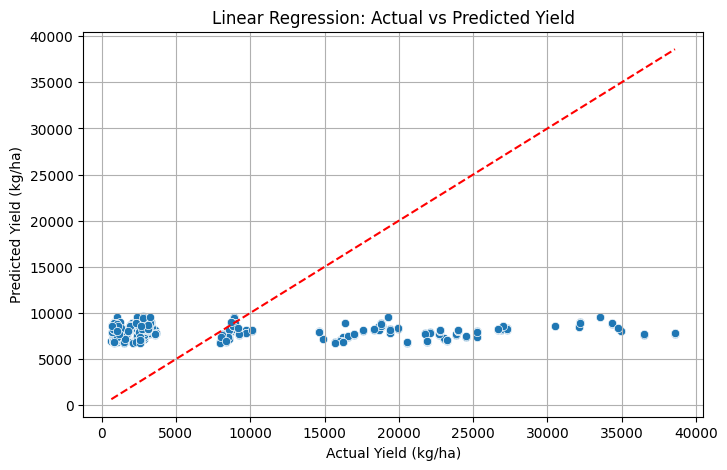

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title('Linear Regression: Actual vs Predicted Yield')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.grid(True)
plt.show()

### Plot Random Forest: Actual v/s Predicted Yield

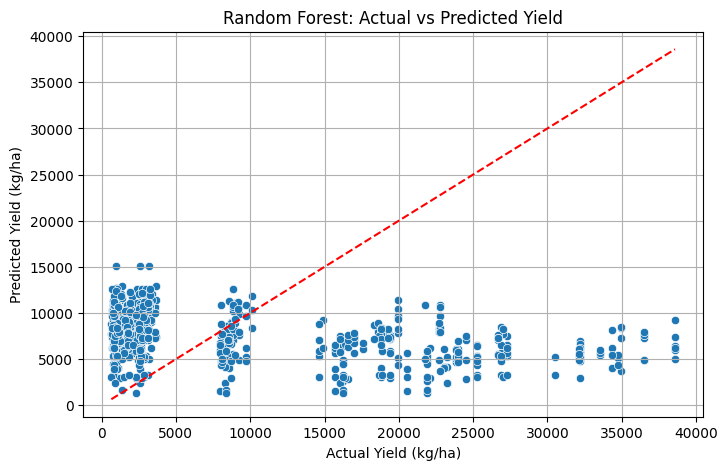

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title('Random Forest: Actual vs Predicted Yield')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.grid(True)
plt.show()

### Example input for future prediction

In [13]:
future_data = pd.DataFrame({
    'average_rain_fall_mm_per_year': [950],
    'avg_temp': [25],
    'pesticides_tonnes': [5000]
})

### Predict future yield using Random Forest model

In [14]:
future_yield_pred = rf_model.predict(future_data)

print("🔷 Future Yield Prediction:", future_yield_pred[0], "kg/ha")

🔷 Future Yield Prediction: 8989.779098732313 kg/ha
